### **Remote Path**

In [1]:
import sys

sys.path.append('/home/dyuser-e/NI_project_dyuser-e_2026/dynap-se1')

### **Local Path**

In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

### **Imports**

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from tools.spikegen_tools import get_instantaneous_activity


### **Remote Connection**

In [ ]:
# get index for board (DONT USE TO CONNECT)

model, _ = ut.open_dynapse1(gui=False, select_device=True)

In [ ]:
model = ut.open_specific_device_in_sequence(3)

### **Local Connection**

In [4]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 4 Dynapse1DevKit serial_number 00000033
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000033
Sender port: tcp://0.0.0.0:43643
Receiver port: tcp://0.0.0.0:37947
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


### Initialize Dynap-SE

In [ ]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters


config1     = model.get_configuration() 

param_group0 = config1.chips[0].cores[0].parameter_group 
param_group1 = config1.chips[0].cores[1].parameter_group 
param_group2 = config1.chips[0].cores[2].parameter_group 
param_group3 = config1.chips[0].cores[3].parameter_group 

### **Set Neuron/Dendrite Parameters - param_mat**

In [ ]:
"""Populations on Core : S, I"""

# set AMPA (fast excitatory) weight 
param_group0.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 110
param_group0.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group0.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 90    
param_group0.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group0.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_F_N'].fine_value =  70      
param_group0.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5


# set AMPA (fast exc) tau 
param_group0.param_map['NPDPIE_TAU_F_P'].fine_value   = 30      # 50
param_group0.param_map['NPDPIE_TAU_F_P'].coarse_value = 2

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group0.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group0.param_map['NPDPIE_TAU_S_P'].coarse_value = 5

# set GABA A (fast inhibitory) tau                              
param_group0.param_map['NPDPII_TAU_F_P'].fine_value = 40
param_group0.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group0.param_map['NPDPII_TAU_S_P'].fine_value = 35
param_group0.param_map['NPDPII_TAU_S_P'].coarse_value = 4


# Neuron membrane voltage gain
param_group0.param_map['IF_THR_N'].fine_value = 100
param_group0.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group0.param_map['IF_RFR_N'].fine_value = 40
param_group0.param_map['IF_RFR_N'].coarse_value = 3

# Bias Current 
param_group0.param_map['IF_DC_P'].fine_value = 20
param_group0.param_map['IF_DC_P'].coarse_value = 0



In [ ]:
"""Populations on Core : SpikeGens"""

# set AMPA (fast excitatory) weight 
param_group1.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 120     #100
param_group1.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group1.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80    #before 70nottoday
param_group1.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group1.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group1.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group1.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group1.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group1.param_map['NPDPIE_TAU_F_P'].fine_value   = 40    #30
param_group1.param_map['NPDPIE_TAU_F_P'].coarse_value = 3

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group1.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group1.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group1.param_map['NPDPII_TAU_F_P'].fine_value = 60
param_group1.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group1.param_map['NPDPII_TAU_S_P'].fine_value = 50
param_group1.param_map['NPDPII_TAU_S_P'].coarse_value = 4



# Neuron membrane voltage gain
param_group1.param_map['IF_THR_N'].fine_value = 100
param_group1.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group1.param_map['IF_RFR_N'].fine_value = 80
param_group1.param_map['IF_RFR_N'].coarse_value = 2

# Bias Current 
param_group1.param_map['IF_DC_P'].fine_value = 0
param_group1.param_map['IF_DC_P'].coarse_value = 0


In [ ]:
"""Populations on Core : T """

# set AMPA (fast excitatory) weight 
param_group2.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 150
param_group2.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group2.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 100    #before 70
param_group2.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group2.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group2.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group2.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group2.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group2.param_map['NPDPIE_TAU_F_P'].fine_value   = 30   #20
param_group2.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group2.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group2.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group2.param_map['NPDPII_TAU_F_P'].fine_value = 60
param_group2.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group2.param_map['NPDPII_TAU_S_P'].fine_value = 50
param_group2.param_map['NPDPII_TAU_S_P'].coarse_value = 4



# Neuron membrane voltage gain
param_group2.param_map['IF_THR_N'].fine_value = 50
param_group2.param_map['IF_THR_N'].coarse_value = 4

# Refactory period (Base 4, 128?)
#param_group2.param_map['IF_RFR_N'].fine_value = 10
#param_group2.param_map['IF_RFR_N'].coarse_value = 3

# Bias Current 
param_group2.param_map['IF_DC_P'].fine_value = 0
param_group2.param_map['IF_DC_P'].coarse_value = 0


In [ ]:
"""Populations on Core : IIT, IIT, Sum"""

# set AMPA (fast excitatory) weight 
param_group3.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 100    #max90
param_group3.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group3.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80    #before 70
param_group3.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group3.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100       #max120
param_group3.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group3.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group3.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group3.param_map['NPDPIE_TAU_F_P'].fine_value   = 30         #max10
param_group3.param_map['NPDPIE_TAU_F_P'].coarse_value = 3

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group3.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group3.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group3.param_map['NPDPII_TAU_F_P'].fine_value = 60           #max20
param_group3.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group3.param_map['NPDPII_TAU_S_P'].fine_value = 20         #max50
param_group3.param_map['NPDPII_TAU_S_P'].coarse_value = 4       #max3



# Neuron membrane voltage gain
#param_group3.param_map['IF_THR_N'].fine_value = 90
#param_group3.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group3.param_map['IF_RFR_N'].fine_value = 60
param_group3.param_map['IF_RFR_N'].coarse_value = 4

# Bias Current 
param_group3.param_map['IF_DC_P'].fine_value = 50
param_group3.param_map['IF_DC_P'].coarse_value = 0




In [70]:
# print AMPA weight values

print("\n--- AMPA (fast excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))


# print NMDA (slow excitatory) weight

print("\n--- NMDA (slow excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))


# print GABA B (slow inhibitory) weight

print("\n--- GABA B (slow inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))


# print GABA A (fast inhibitory) weight

print("\n--- GABA A (fast inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))


# print NMDA (slow exc) tau

print("\n--- NMDA tau (slow excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))


# print AMPA (fast exc) tau

print("\n--- AMPA tau (fast excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))


# refactory period

print("\n--- Refractory period ---")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].fine_value))


print("\n--- Neuron membrane voltage gain ---")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_THR_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['IF_THR_N'].fine_value))




--- AMPA (fast excitatory) weight ---
Linear: 125490200.0
Coarse: 6
Fine: 100

--- NMDA (slow excitatory) weight ---
Linear: 6274510.0
Coarse: 5
Fine: 40

--- GABA B (slow inhibitory) weight ---
Linear: 7843138.0
Coarse: 5
Fine: 50

--- GABA A (fast inhibitory) weight ---
Linear: 12549020.0
Coarse: 5
Fine: 80

--- NMDA tau (slow excitatory) ---
Linear: 491961.0
Coarse: 4
Fine: 25

--- AMPA tau (fast excitatory) ---
Linear: 1568628.0
Coarse: 4
Fine: 80

--- Refractory period ---
Coarse: 4
Fine: 40

--- Neuron membrane voltage gain ---
Coarse: 5
Fine: 100


### **Set Network Parameters**

#### Set Connection Probabilites

In [ ]:

model.update_parameter_group(param_group0, 0, 0)
model.update_parameter_group(param_group1, 0, 1)
model.update_parameter_group(param_group2, 0, 2)
model.update_parameter_group(param_group3, 0, 3)

NE = 8          # neurons per excitatory state population
NI = 8          # inhibitory population size
NS = 3           # number of excitatory state populations
NG = 3           # Nr of spike generators


exclude_n_ids = [(0,0,159),(0,0,242),(0,0,247),
                 (0,1,6),(0,1,71),(0,1,119),(0,1,223),
                 (0,2,29),(0,2,65),(0,2,172),(0,2,206),
                 (0,3,9),(0,3,64),(0,3,86),(0,3,183),(0,3,188),(0,3,214),(0,3,239)]

seed = 20

p_S_S_base, p_S_S_frac     = np.full(NS, 0.0), np.full(NS, 0.0)       # AMPA base prob, NMDA fraction
p_S_I_base, p_S_I_frac     = np.full(NS, 0.0), np.full(NS, 0.0)       # AMPA base prob, NMDA fraction
p_I_S_base, p_I_S_frac     = np.full(NS, 0.0), np.full(NS, 0.0)       # GABA_A base prob, GABA_B fraction

p_S_S_self                 = np.full(NS, 0.0)

p_I_I                      = 0.0                                      # GABA_A base prob
p_G_S                      = 1.0                                      # spike generator to state population


identical_connections    = True # Create exact same connections for s populations
pop_specific_connections = False # Apply population specific connection probabilities

#### Adjust Connection Probabilities Population Specific

In [72]:
if pop_specific_connections is True:
    s = 0

    p_S_S_base[s]   = p_S_S_base[s] - 0.0
    p_S_S_frac[s]   = p_S_S_frac[s] - 0.0
    p_S_S_self[s]   = p_S_S_self[s] - 0.0

    p_I_S_base[s]   = p_I_S_base[s]

#### **Define Spike Input Rates**

In [ ]:
lr    = 0       # low rate (Hz)
hr    = 70      # high rate (Hz)

stim_rates = np.linspace(lr,lr,10)
stim_rates_hz = [[rate, 0, 0] for rate in stim_rates ]

stim_rates_hz[2][0] = hr
stim_rates_hz[3][0] = hr
stim_rates_hz[4][0] = hr
stim_rates_hz[5][0] = hr

dt_stim       = 0.5
t_steps_stim  = dt_stim*np.ones_like(stim_rates)
t_post_stim   = 3.0
t_tot         = sum(t_steps_stim) + t_post_stim

print(t_tot)

8.0


### **Build Network**

In [74]:

rng = np.random.default_rng(seed)

net_gen = NetworkGenerator()
net_gen.clear_network()


#### Create Populations

In [75]:
def make_population(
    size,
    next_true_nid,
    next_disp_idx,
    chip,             
    core,             
    exclude_n_ids,    
    true_to_disp_idx,
    is_spikegen = False,
):
    exclude_n_ids = set(exclude_n_ids or [])

    pop_ids = []
    nid     = next_true_nid

    while len(pop_ids) < size:

        true_id = (chip, core, nid)

        if true_id not in exclude_n_ids:
            pop_ids.append(true_id)

            true_to_disp_idx[true_id] = next_disp_idx
            next_disp_idx += 1

        nid += 1

    pop = [Neuron(chip_, core_, nid_, is_spikegen) for chip_, core_, nid_ in pop_ids]

    next_true_nid = nid

    return pop, pop_ids, next_true_nid, true_to_disp_idx, next_disp_idx

In [76]:

S_pops = []
E_ids  = []

next_true_nid       = 1                 # index as appears on the dynapse
next_disp_idx       = 0                 # index as displayed on plots
true_to_disp_idx    = {}                # dictionary mapping true dynapse index to displayed index

for s in range(NS):

    S_pop, S_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NE,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = core_id,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )

    S_pops.append(S_pop)
    E_ids.extend(S_ids)


I_pop, I_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NI,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = core_id,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )


spikegens, spikegen_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NG,
        next_true_nid      = 1,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = 1,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
        is_spikegen        = True
    )


#### Connection Matrix

In [77]:
# ------------------------------------------------------------
# CONSTRUCT CONNECTION MATRIX
# ------------------------------------------------------------

N_hw  = NE * NS + NI   # all real neurons
N_tot = N_hw + NG      # real neurons + spike generators

C = np.zeros((N_tot, N_tot))


def get_idx(n):
    true_id = (0, n.core_id, n.neuron_id)

    return true_to_disp_idx[true_id]


def add_conn(src, tgt, syn_type):
    net_gen.add_connection(src, tgt, syn_type)

    src_idx = get_idx(src)
    tgt_idx = get_idx(tgt)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_idx, tgt_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_idx, tgt_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_idx, tgt_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_idx, tgt_idx] = -2

#### Create Connections

In [78]:

def make_connections(N_pre, N_post, p_base, p_frac, sync_pop_conns=False):
    conns_all = []

    N_tot = N_pre * N_post

    for i in range(len(p_base)):

        n_conn  = int(round(N_tot * p_base[i]))
        n_type2 = int(round(n_conn * p_frac[i]))
        n_type1 = n_conn - n_type2
        n_zero  = N_tot - n_conn

        conns = np.array(
            [1] * n_type1 +
            [2] * n_type2 +
            [0] * n_zero
        )

        np.random.shuffle(conns)

        conns = conns.reshape(N_post, N_pre)

        conns_all.append(conns)

    if sync_pop_conns:
        conns_all = [conns_all[0].copy() for _ in conns_all]

    return conns_all


def make_square_connections(N, p_base, p_frac, p_self=0.0, sync_pop_conns=False):
    conns_all = []

    n_offdiag_possible = N * N - N

    for i in range(len(p_base)):

        n_total = int(round(n_offdiag_possible * p_base[i]))
        n_self  = int(round(N * p_self[i]))
        n_self  = min(n_self, N, n_total)
        
        n_offdiag = n_total - n_self

        n_type2 = int(round(n_total * p_frac[i]))
        n_type1 = n_total - n_type2

        conn_values = np.array(
            [1] * n_type1 +
            [2] * n_type2
        )

        np.random.shuffle(conn_values)

        self_values    = conn_values[:n_self]
        offdiag_values = conn_values[n_self:]

        conns = np.zeros((N, N), dtype=int)

        offdiag_mask = ~np.eye(N, dtype=bool)

        offdiag_indices = np.where(offdiag_mask.ravel())[0]
        chosen_offdiag  = np.random.choice(
            offdiag_indices,
            size=n_offdiag,
            replace=False
        )

        conns.ravel()[chosen_offdiag] = offdiag_values

        if n_self > 0:
            diag_indices = np.random.choice(N, size=n_self, replace=False)
            conns[diag_indices, diag_indices] = self_values

        conns_all.append(conns)

    if sync_pop_conns:
        conns_all = [conns_all[0].copy() for _ in conns_all]

    return conns_all

def add_conns_from_matrix(pre_pop, post_pop, conn_matrix, synapse_map):
    """
    conn_matrix[post_idx, pre_idx]
    """

    post_ids, pre_ids = np.nonzero(conn_matrix)

    for post_idx, pre_idx in zip(post_ids, pre_ids):

        syn_code = int(conn_matrix[post_idx, pre_idx])
        syn_type = synapse_map[syn_code]

        add_conn(
            pre_pop[pre_idx],
            post_pop[post_idx],
            syn_type
        )

In [79]:
s_s_conns = make_square_connections(NE, p_S_S_base, p_S_S_frac, p_S_S_self, identical_connections)
s_I_conns = make_connections(NE, NI, p_S_I_base, p_S_I_frac, identical_connections)
I_s_conns = make_connections(NI, NE, p_I_S_base, p_I_S_frac, identical_connections)

In [80]:
exc_synapse_map = {
    1: dyn1.Dynapse1SynType.AMPA,
    2: dyn1.Dynapse1SynType.NMDA
}

inh_synapse_map = {
    1: dyn1.Dynapse1SynType.GABA_A,
    2: dyn1.Dynapse1SynType.GABA_B
}

In [81]:

for s in range(NS):
    n_g_s = int(round(NE * p_G_S))

    for neuron in S_pops[s][:n_g_s]:
        add_conn(
            spikegens[s],
            neuron,
            dyn1.Dynapse1SynType.AMPA
        )

for s in range(NS):
    add_conns_from_matrix(S_pops[s], S_pops[s], s_s_conns[s], exc_synapse_map)
    add_conns_from_matrix(S_pops[s], I_pop,     s_I_conns[s], exc_synapse_map)
    add_conns_from_matrix(I_pop,     S_pops[s], I_s_conns[s], inh_synapse_map)


### **Plot Connection Matrix**

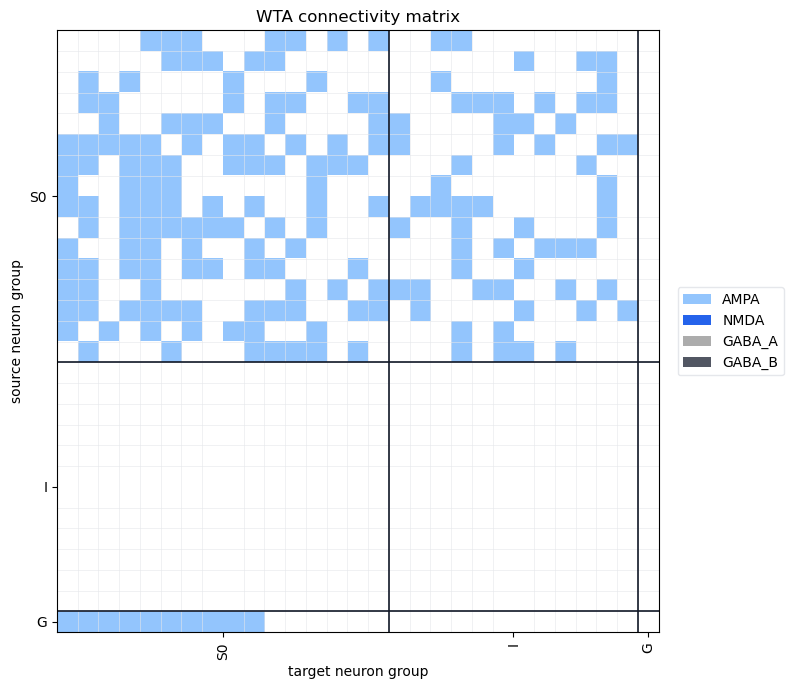

In [82]:

plt.clf()
plt.close("all")

fig, ax = plt.subplots(figsize=(8, 8))


# ------------------------------------------------------------
# DISCRETE SYNAPSE COLORS
# ------------------------------------------------------------
syn_colors = {
    "GABA_B": "#525763",
    "GABA_A": "#acacac",
    "none":   "#ffffff",
    "AMPA":   "#93c5fd",
    "NMDA":   "#2563eb",
}

colors = [
    syn_colors["GABA_B"],
    syn_colors["GABA_A"],
    syn_colors["none"],
    syn_colors["AMPA"],
    syn_colors["NMDA"],
]

cmap = ListedColormap(colors)

bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm   = BoundaryNorm(bounds, cmap.N)


# ------------------------------------------------------------
# CONNECTIVITY MATRIX
# ------------------------------------------------------------
im = ax.imshow(
    C,
    cmap          = cmap,
    norm          = norm,
    interpolation = "none",
    aspect        = "equal"
)


# ------------------------------------------------------------
# GROUP DEFINITIONS
# Matrix ordering assumed:
# S0, S1, ..., S_NS-1, G, I
# ------------------------------------------------------------
NG = NS          # one input generator per state population

group_specs = []

for s in range(NS):
    group_specs.append((f"S{s}", NE))

group_specs.append(("I", NI))
group_specs.append(("G", NG))

group_sizes  = [size for _, size in group_specs]
group_labels = [name for name, _ in group_specs]

N_plot = sum(group_sizes)

if C.shape != (N_plot, N_plot):
    raise ValueError(
        f"C has shape {C.shape}, but group sizes imply "
        f"({N_plot}, {N_plot}). Check group ordering or sizes."
    )


# ------------------------------------------------------------
# CELL GRID
# ------------------------------------------------------------
ax.set_xticks(np.arange(N_plot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_plot + 1) - 0.5, minor=True)

ax.grid(
    which     = "minor",
    color     = "#e5e7eb",
    linestyle = "-",
    linewidth = 0.4
)

ax.tick_params(which="minor", bottom=False, left=False)


# ------------------------------------------------------------
# GROUP BOUNDARIES
# ------------------------------------------------------------
boundaries = np.cumsum(group_sizes)

boundary_color = "#111827"

for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color=boundary_color, linewidth=1.2)
    ax.axvline(b - 0.5, color=boundary_color, linewidth=1.2)


# ------------------------------------------------------------
# GROUP LABELS
# ------------------------------------------------------------
centers = boundaries - np.array(group_sizes) / 2 - 0.5

ax.set_xticks(centers)
ax.set_yticks(centers)

ax.set_xticklabels(group_labels, rotation=90)
ax.set_yticklabels(group_labels)

ax.set_xlabel("target neuron group")
ax.set_ylabel("source neuron group")
ax.set_title("WTA connectivity matrix")


# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor=syn_colors["AMPA"],   edgecolor="none", label="AMPA"),
    Patch(facecolor=syn_colors["NMDA"],   edgecolor="none", label="NMDA"),
    Patch(facecolor=syn_colors["GABA_A"], edgecolor="none", label="GABA_A"),
    Patch(facecolor=syn_colors["GABA_B"], edgecolor="none", label="GABA_B"),
]

ax.legend(
    handles    = legend_elements,
    loc        = "center left",
    bbox_to_anchor = (1.02, 0.5),
    frameon    = True,
    framealpha = 1.0,
    edgecolor  = "#e5e7eb"
)

plt.tight_layout()
plt.show()

In [83]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

model.update_parameter_group(param_group, 0, core_id)

# ------------------------------------------------------------
# PREPARE INPUT
# ------------------------------------------------------------
global_spikegen_ids    = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gen_id in global_spikegen_ids:
    poisson_gen.write_poisson_rate_hz(gen_id, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------
monitored_neurons = E_ids + I_ids
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()

# filter_node.set_neurons(monitored_neurons)

# clear buffer
sink_node.get_events()
api.reset_timestamp()

New configuration applied to DYNAP-SE1!


### **Create Input Spike-Train**

In [84]:
# ------------------------------------------------------------
# CREATE POISSON SPIKE TIMES
# ------------------------------------------------------------

spike_times  = []
indices      = []
target_chips = []

t0 = 0.0

for i, duration in enumerate(t_steps_stim):

    for gen_id, rate in zip(global_spikegen_ids, stim_rates_hz[i]):

        n_spikes = np.random.poisson(rate * duration)
        
        times = t0 + np.sort(np.random.rand(n_spikes) * duration)
        
        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    t0 += duration


# sort all spikes globally in time:
spike_times  = np.array(spike_times)
indices      = np.array(indices)
target_chips = np.array(target_chips)

sort_idx = np.argsort(spike_times)

spike_times  = spike_times[sort_idx]
indices      = indices[sort_idx]
target_chips = target_chips[sort_idx]


# load the stimulus:
fpga_spike_gen = model.get_fpga_spike_gen()

ut.set_fpga_spike_gen(
    fpga_spike_gen = fpga_spike_gen,
    spike_times    = spike_times,
    indices        = indices,
    target_chips   = target_chips,
    isi_base       = 900,
    repeat_mode    = False
)

VariableIsiMode already 1
RepeatMode already 0


In [85]:
# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.2
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < t_tot)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, t_tot, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < t_tot

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x


### **Plot Stimulation Rates**

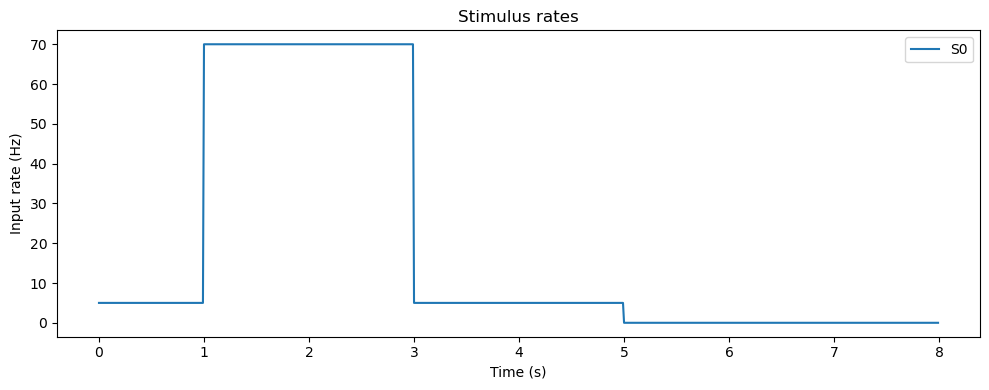

In [86]:

fs = 100

stim_rates_hz = np.array(stim_rates_hz)
t             = np.arange(0, t_tot, 1/fs)

# allocate rate matrix
rates = np.zeros((NS, len(t)))

# fill piecewise constant segments
t_cursor = 0
for i, dt in enumerate(t_steps_stim):
    idx_start = int(t_cursor * fs)
    idx_end   = int((t_cursor + dt) * fs)

    for s in range(NS):
        rates[s, idx_start:idx_end] = stim_rates_hz[i, s]

    t_cursor += dt

plt.figure(figsize=(10,4))

for s in range(NS):
    plt.plot(t, rates[s], label=f"S{s}")

plt.xlabel("Time (s)")
plt.ylabel("Input rate (Hz)")
plt.title("Stimulus rates")
plt.legend()
plt.tight_layout()
plt.show()


#### Define Parameter Sweep

In [ ]:
param_val_index = ut._bias_as_idx(((4,80)),'tuple')
print(param_val_index)

967


In [185]:
# param_sweep_vals = [int(v) for v in np.round(np.linspace(0, 400, 6))]        # Bias Current
# param_sweep_vals = [int(v) for v in np.round(np.linspace(100, 400, 6))]      # Voltage Gain
# param_sweep_vals = [int(v) for v in np.round(np.linspace(100, 1200, 10))]      # Refactory period

param_sweep_vals = [int(v) for v in np.round(np.linspace(50, 400, 10))]      # AMPA Tau
# param_sweep_vals = [int(v) for v in np.round(np.linspace(800, 1500, 6))]     # AMPA W

# param_sweep_vals = [int(v) for v in np.round(np.linspace(800, 1400, 6))]     # GABA_A W
# param_sweep_vals = [int(v) for v in np.round(np.linspace(700, 1200, 6))]     # GABA_A Tau

# param_sweep_vals = [int(v) for v in np.round(np.linspace(1000, 1400, 6))]    # W GABA_B

print(f"{'index':>8} | {'coarse':>6} | {'fine':>6}")
print("-" * 29)

for val in param_sweep_vals:

    coarse, fine = ut._bias_as_tuple(val, "index")

    print(f"{val:8d} | {coarse:6d} | {fine:6d}")

   index | coarse |   fine
-----------------------------
      50 |      0 |     50
      89 |      0 |     89
     128 |      0 |    128
     167 |      0 |    167
     206 |      0 |    206
     244 |      0 |    244
     283 |      1 |     64
     322 |      1 |    103
     361 |      1 |    142
     400 |      1 |    181


In [186]:
ut.set_neuron_gain(model, chip_id=0, core_id=core_id, bias_value=int(300), bias_format='index')
ut.set_neuron_dc(model,   chip_id=0, core_id=core_id, bias_value=int(0), bias_format='index')
ut.set_neuron_refractory_period(model, chip_id=0, core_id=core_id, bias_value=int(500), bias_format='index')


ut.set_ampa_tau(model,     chip_id=0, core_id=core_id, bias_value=int(150), bias_format='index')
ut.set_ampa_weight(model,  chip_id=0, core_id=core_id, bias_value=int(1300), bias_format='index')

ut.set_gaba_a_weight(model,  chip_id=0, core_id=core_id, bias_value=int(1240), bias_format='index')
ut.set_gaba_a_tau(model,  chip_id=0, core_id=core_id, bias_value=int(970), bias_format='index')


### **Run Simulation**

In [187]:
events_from_sweep = []

for param_val in param_sweep_vals:

    # ------------------------------------------------------------
    #  PARAMETRS    
    # ------------------------------------------------------------

    print(int(param_val))

    # ut.set_neuron_gain(model, chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')

    # ut.set_neuron_refractory_period(model, chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')
    # ut.set_neuron_dc(model,                chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')

    # ut.set_ampa_weight(model,  chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')
    ut.set_ampa_tau(model,     chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')


    # ut.set_nmda_weight(model,  chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')
    # ut.set_nmda_tau(model,     chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')

    # ut.set_gaba_a_tau(model,   chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')

    # ut.set_gaba_b_weight(model, chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')
    # ut.set_gaba_b_tau(model,    chip_id=0, core_id=core_id, bias_value=int(param_val), bias_format='index')

    # ------------------------------------------------------------
    #  SPIKEGEN INPUT
    # ------------------------------------------------------------
    global_spikegen_ids = ut.get_global_id_list(spikegen_ids)
    poisson_gen            = model.get_poisson_gen()
    poisson_gen.set_chip_id(0)

    for gen_id in global_spikegen_ids:          # set initial rates to zero
        poisson_gen.write_poisson_rate_hz(gen_id, 0)

    # ------------------------------------------------------------
    # MONITOR NEURONS
    # ------------------------------------------------------------

    monitored_neurons = E_ids + I_ids
    graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
    graph.start()

    sink_node.get_events()                  # clear buffer
    api.reset_timestamp()


    # Run Simulation
    fpga_spike_gen.start()
    time.sleep(t0)
    fpga_spike_gen.stop()


    for gen_id in global_spikegen_ids:      # turn off stimulus
        poisson_gen.write_poisson_rate_hz(gen_id, 0)

    poisson_gen.stop()
    time.sleep(t_tot)

    graph.stop()
    events = sink_node.get_events()
    
    print(f"{len(events)} events recorded.")

    events_from_sweep.append(events)
    

50
PoissonGen already off!
1051 events recorded.
89
PoissonGen already off!
825 events recorded.
128
PoissonGen already off!
658 events recorded.
167
PoissonGen already off!
528 events recorded.
206
PoissonGen already off!
404 events recorded.
244
PoissonGen already off!
285 events recorded.
283
PoissonGen already off!
111 events recorded.
322
PoissonGen already off!
67 events recorded.
361
PoissonGen already off!
48 events recorded.
400
PoissonGen already off!
44 events recorded.


### **Post Simulation Processing**

In [188]:
# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

fs = 3

NS_int = int(NS)
NE_int = int(NE)
NI_int = int(NI)

N_hw   = NS_int * NE_int + NI_int
n_bins = int(t_tot * fs)
idx_end = n_bins

t_axis = np.arange(idx_end) / fs

pop_sizes  = np.r_[np.full(NS_int, NE_int), NI_int]
pop_labels = [f"S{s}" for s in range(NS_int)] + ["I"]


# ------------------------------------------------------------
# PROCESS ONE EVENT LIST
# ------------------------------------------------------------

def process_events(events):

    spike_id_true = []
    spike_id      = []
    spike_t       = []

    for evt in events:

        true_id = (0, 0, int(evt.neuron_id))

        if true_id not in true_to_disp_idx:
            continue

        disp_id = true_to_disp_idx[true_id]

        if disp_id >= N_hw:
            continue

        spike_id_true.append(evt.neuron_id)
        spike_id.append(disp_id)
        spike_t.append(evt.timestamp * 1e-6)

    spike_id_true = np.asarray(spike_id_true)
    spike_id      = np.asarray(spike_id)
    spike_t       = np.asarray(spike_t)


    # ------------------------------------------------------------
    # FILTER SPIKES BY POPULATION
    # ------------------------------------------------------------

    S_spike_t  = []
    S_spike_id = []

    for s in range(NS_int):

        lower = s * NE_int
        upper = (s + 1) * NE_int

        mask = (spike_id >= lower) & (spike_id < upper)

        S_spike_t.append(spike_t[mask])
        S_spike_id.append(spike_id[mask])

    lower_I = NS_int * NE_int
    upper_I = NS_int * NE_int + NI_int

    mask_I = (spike_id >= lower_I) & (spike_id < upper_I)

    I_spike_t  = spike_t[mask_I]
    I_spike_id = spike_id[mask_I]


    # ------------------------------------------------------------
    # BIN FILTERED SPIKES
    # ------------------------------------------------------------

    binPOP = np.zeros((NS_int + 1, n_bins))

    for s in range(NS_int + 1):

        if s < NS_int:
            t_spikes = S_spike_t[s]
        else:
            t_spikes = I_spike_t

        t_spikes = t_spikes[t_spikes < t_tot]

        counts, _ = np.histogram(
            t_spikes,
            bins  = n_bins,
            range = (0, t_tot)
        )

        binPOP[s, :] = counts


    # total excitatory activity, all S populations pooled
    binPOP_E = np.sum(binPOP[:NS_int, :], axis=0)

    # mean number of spikes per excitatory neuron over full simulation
    binPOP_tot_mean = np.sum(binPOP[:NS_int, :]) / (NS_int * NE_int)


    # ------------------------------------------------------------
    # POPULATION FIRING ACTIVITY
    # ------------------------------------------------------------

    binPOP_rate = binPOP[:, :idx_end] * fs / pop_sizes[:, None]


    # ------------------------------------------------------------
    # FIRING ACTIVITY PER STIMULUS WINDOW
    # ------------------------------------------------------------

    stim_start = np.cumsum(np.r_[0, t_steps_stim[:-1]])
    stim_end   = stim_start + t_steps_stim

    out_rates = np.zeros((NS_int, len(stim_start)))

    for s in range(NS_int):

        for i, (t_start, t_stop) in enumerate(zip(stim_start, stim_end)):

            b0 = int(t_start * fs)
            b1 = int(t_stop  * fs)

            n_spikes = np.sum(binPOP[s, b0:b1])

            out_rates[s, i] = n_spikes / ((t_stop - t_start) * NE_int)

    # ------------------------------------------------------------
    # POPULATION ACTIVITY USING population_activity()
    # ------------------------------------------------------------

    S_activity_rate = []
    S_activity_x    = []

    for s in range(NS_int):

        rate, x = population_activity(S_spike_t[s], NE_int)

        S_activity_rate.append(rate)
        S_activity_x.append(x)


    I_activity_rate, I_activity_x = population_activity(I_spike_t, NI_int)


    # total excitatory activity, all S populations pooled
    E_spike_t = np.concatenate(S_spike_t)

    E_activity_rate, E_activity_x = population_activity(
        E_spike_t,
        NS_int * NE_int
    )

    return {
        "spike_id_true"    : spike_id_true,
        "spike_id"         : spike_id,
        "spike_t"          : spike_t,

        "S_spike_t"        : S_spike_t,
        "S_spike_id"       : S_spike_id,
        "I_spike_t"        : I_spike_t,
        "I_spike_id"       : I_spike_id,

        "S_activity_rate"  : S_activity_rate,
        "S_activity_x"     : S_activity_x,
        "I_activity_rate"  : I_activity_rate,
        "I_activity_x"     : I_activity_x,
        "E_activity_rate"  : E_activity_rate,
        "E_activity_x"     : E_activity_x,

        "binPOP"           : binPOP,
        "binPOP_E"         : binPOP_E,
        "binPOP_tot_mean"  : binPOP_tot_mean,
        "binPOP_rate"      : binPOP_rate,
        "out_rates"        : out_rates,
    }


# ------------------------------------------------------------
# PROCESS FULL PARAMETER SWEEP
# ------------------------------------------------------------

sweep_data = []

for param_val, events in zip(param_sweep_vals, events_from_sweep):

    data = process_events(events)
    data["param_val"] = param_val

    sweep_data.append(data)

    print(
        f"param = {param_val:.1f}: "
        f"{len(data['spike_t'])} spikes, "
        f"mean E spikes/neuron = {data['binPOP_tot_mean']:.2f}"
    )

param = 50.0: 1051 spikes, mean E spikes/neuron = 25.44
param = 89.0: 825 spikes, mean E spikes/neuron = 20.81
param = 128.0: 658 spikes, mean E spikes/neuron = 17.38
param = 167.0: 528 spikes, mean E spikes/neuron = 14.44
param = 206.0: 404 spikes, mean E spikes/neuron = 12.38
param = 244.0: 285 spikes, mean E spikes/neuron = 10.06
param = 283.0: 111 spikes, mean E spikes/neuron = 5.44
param = 322.0: 67 spikes, mean E spikes/neuron = 3.31
param = 361.0: 48 spikes, mean E spikes/neuron = 2.38
param = 400.0: 44 spikes, mean E spikes/neuron = 2.06


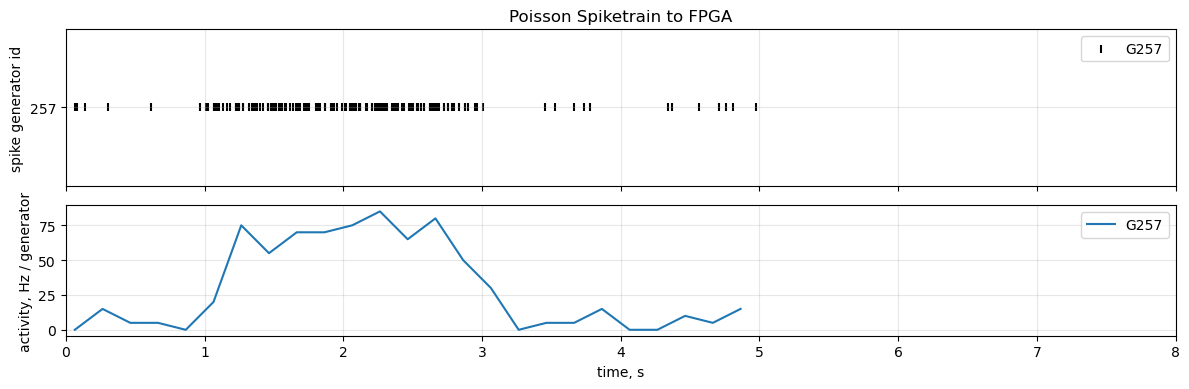

In [189]:
input_spike_t  = np.asarray(spike_times)
input_spike_id = np.asarray(indices)

color_in = 'black'

# ------------------------------------------------------------
# COMPUTE INPUT GENERATOR ACTIVITY
# ------------------------------------------------------------
G_activity_rate = []
G_activity_x    = []
G_ids           = np.unique(input_spike_id)

for gid in G_ids:
    mask = input_spike_id == gid
    rate, x = population_activity(input_spike_t[mask], n_neurons=10)

    G_activity_rate.append(rate)
    G_activity_x.append(x)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1]}
)

# ------------------------------------------------------------
# RASTER
# ------------------------------------------------------------
for gid in G_ids:
    mask = input_spike_id == gid

    ax1.scatter(
        input_spike_t[mask],
        input_spike_id[mask],
        marker='|',
        s=30,
        color=color_in,
        label=f'G{gid}'
    )

ax1.set_ylabel('spike generator id')
ax1.set_title('Poisson Spiketrain to FPGA')

ax1.set_yticks(G_ids)
ax1.set_yticklabels([str(int(gid)) for gid in G_ids])

ax1.grid(True, alpha=0.3)
ax1.legend()

# ------------------------------------------------------------
# INSTANTANEOUS ACTIVITY
# ------------------------------------------------------------
for k, gid in enumerate(G_ids):
    ax2.plot(
        G_activity_x[k],
        G_activity_rate[k],
        linestyle='-',
        label=f'G{gid}'
    )

ax2.set_xlabel('time, s')
ax2.set_ylabel('activity, Hz / generator')
ax2.set_xlim(0, t_tot)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [190]:
raster_idx = 3

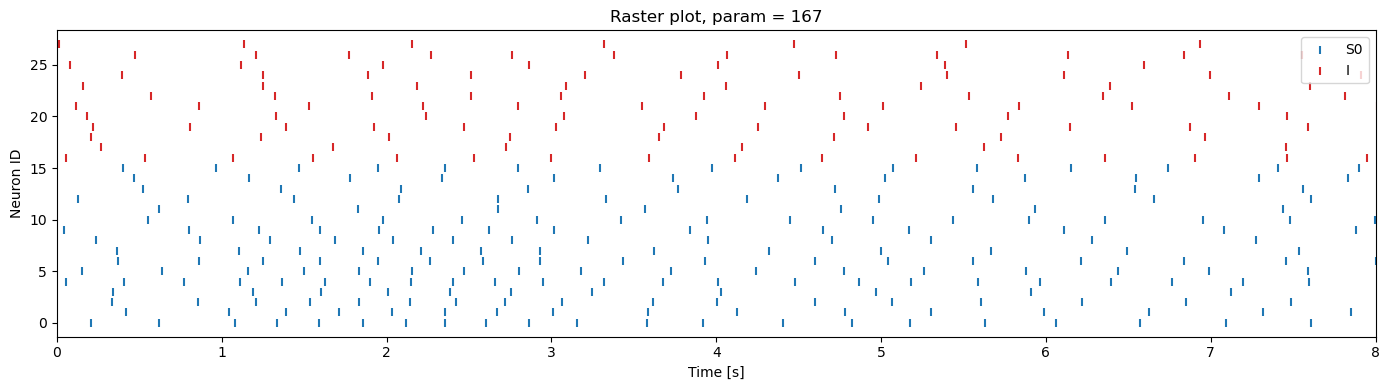

In [191]:
# ------------------------------------------------------------
# PLOT RASTER FOR ONE CHOSEN PARAMETER VALUE
# ------------------------------------------------------------

color_I  = 'tab:red'
color_S  = ['tab:blue', 'tab:orange', 'tab:green', color_I]  # one per S population

raster_param_val = param_sweep_vals[raster_idx]   # choose which parameter value to raster-plot
raster_param_idx = int(np.argmin(np.abs(np.asarray(param_sweep_vals) - raster_param_val)))

data = sweep_data[raster_param_idx]

fig, ax = plt.subplots(figsize=(14, 4))

for s in range(NS_int):

    ax.scatter(
        data["S_spike_t"][s],
        data["S_spike_id"][s],
        marker = "|",
        color  = color_S[s],
        label  = f"S{s}",
    )

if data["I_spike_t"].size > 0:

    ax.scatter(
        data["I_spike_t"],
        data["I_spike_id"],
        marker = "|",
        color  = color_I,
        label  = "I",
    )

ax.set_xlabel("Time [s]")
ax.set_ylabel("Neuron ID")
ax.set_title(f"Raster plot, param = {data['param_val']}")
ax.set_xlim(0, t_tot)

ax.legend()
plt.tight_layout()
plt.show()

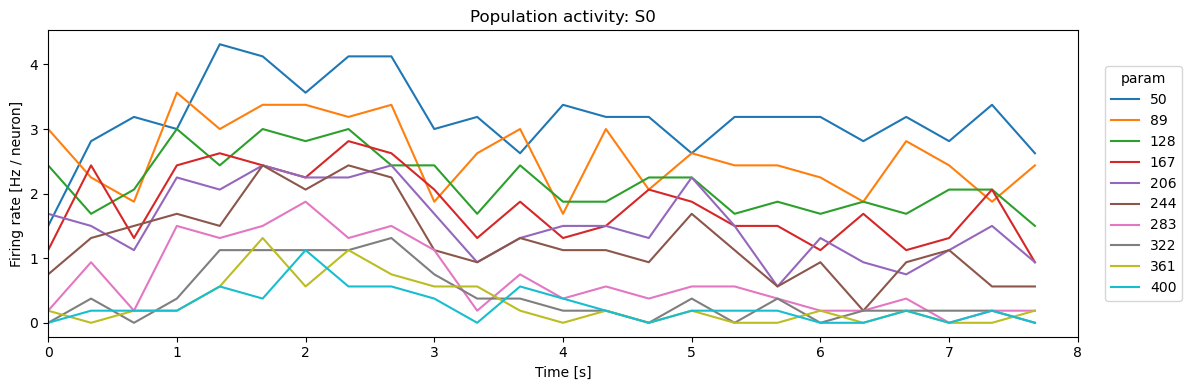

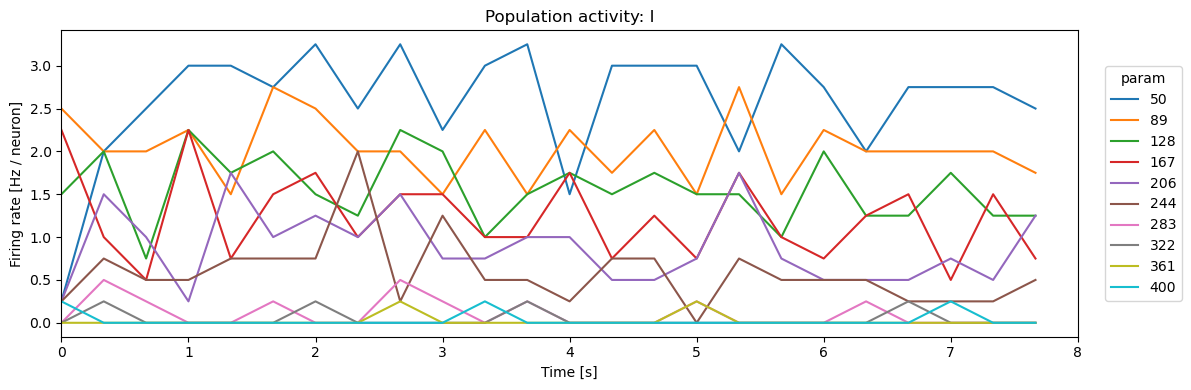

In [192]:
# ------------------------------------------------------------
# PLOT POPULATION ACTIVITY FOR ALL PARAMETER VALUES
# ------------------------------------------------------------

for pop_idx, pop_label in enumerate(pop_labels):

    fig, ax = plt.subplots(figsize=(12, 4))

    for data in sweep_data:

        ax.plot(
            t_axis,
            data["binPOP_rate"][pop_idx],
            label = f"{data['param_val']}",
        )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Firing rate [Hz / neuron]")
    ax.set_title(f"Population activity: {pop_label}")
    ax.set_xlim(0, t_tot)

    ax.legend(
        title          = "param",
        loc            = "center left",
        bbox_to_anchor = (1.02, 0.5),
    )

    plt.tight_layout()
    plt.show()

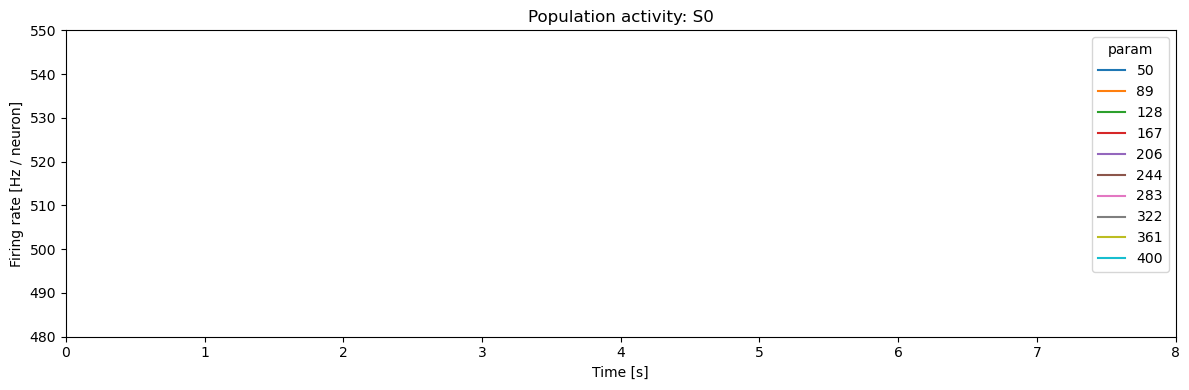

In [193]:
# ------------------------------------------------------------
# PLOT S POPULATION ACTIVITY FROM population_activity()
# ------------------------------------------------------------

for s in range(NS_int):

    fig, ax = plt.subplots(figsize=(12, 4))

    for data in sweep_data:

        ax.plot(
            data["S_activity_x"][s],
            data["S_activity_rate"][s],
            label = f"{data['param_val']}",
        )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Firing rate [Hz / neuron]")
    ax.set_title(f"Population activity: S{s}")
    ax.set_xlim(0, t_tot)
    ax.set_ylim(480,550)

    ax.legend(title="param")
    plt.tight_layout()
    plt.show()

## **Grid Search Sweep**

In [ ]:
param_val_index = ut._bias_as_idx(((4,30)),'tuple')
print(param_val_index)

# voltage gain      1191
# refarcory period  947
# ampa tau          896

896


In [ ]:

# param_sweep_vals = [int(v) for v in np.round(np.linspace(0, 400, 2))]        # Bias Current
param_sweep_vals_1 = [int(v) for v in np.round(np.linspace(100, 500, 4))]     # Voltage Gain
param_sweep_vals_2 = [int(v) for v in np.round(np.linspace(50, 400, 4))]      # AMPA Tau
param_sweep_vals_3 = [int(v) for v in np.round(np.linspace(1000, 1400, 2))]   # W AMPA

print(f"{'index':>8} | {'coarse':>6} | {'fine':>6}")
print("-" * 29)

print("1.")
for val in param_sweep_vals_1:

    coarse, fine = ut._bias_as_tuple(val, "index")

    print(f"{val:8d} | {coarse:6d} | {fine:6d}")

print("2.")
for val in param_sweep_vals_2:

    coarse, fine = ut._bias_as_tuple(val, "index")

    print(f"{val:8d} | {coarse:6d} | {fine:6d}")

print("3.")
for val in param_sweep_vals_3:

    coarse, fine = ut._bias_as_tuple(val, "index")

    print(f"{val:8d} | {coarse:6d} | {fine:6d}")

   index | coarse |   fine
-----------------------------
1.
     100 |      0 |    100
     233 |      0 |    233
     367 |      1 |    148
     500 |      2 |     58
2.
      50 |      0 |     50
     167 |      0 |    167
     283 |      1 |     64
     400 |      1 |    181
3.
    1000 |      4 |    113
    1400 |      6 |     65


In [196]:
events_from_sweep = []

for param_val_1 in param_sweep_vals_1:

    for param_val_2 in param_sweep_vals_2:

        for param_val_3 in param_sweep_vals_3:

            # ------------------------------------------------------------
            #  PARAMETERS
            # ------------------------------------------------------------

            param_val_1 = int(param_val_1)
            param_val_2 = int(param_val_2)
            param_val_3 = int(param_val_3)

            print(
                f"param_1 = {param_val_1}, "
                f"param_2 = {param_val_2}, "
                f"param_3 = {param_val_3}"
            )

            # ------------------------------------------------------------
            #  PARAMETER 1
            # ------------------------------------------------------------

            ut.set_neuron_gain(model, chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')

            # ut.set_neuron_refractory_period(model, chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')
            # ut.set_neuron_dc(model,                chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')

            # ut.set_ampa_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')
            # ut.set_ampa_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')

            # ut.set_nmda_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')
            # ut.set_nmda_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')

            # ut.set_gaba_a_tau(model, chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')

            # ut.set_gaba_b_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')
            # ut.set_gaba_b_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_1, bias_format='index')


            # ------------------------------------------------------------
            #  PARAMETER 2
            # ------------------------------------------------------------

            # ut.set_neuron_gain(model, chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')

            # ut.set_neuron_refractory_period(model, chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')
            # ut.set_neuron_dc(model,                chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')

            # ut.set_ampa_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')
            ut.set_ampa_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')

            # ut.set_nmda_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')
            # ut.set_nmda_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')

            # ut.set_gaba_a_tau(model, chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')

            # ut.set_gaba_b_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')
            # ut.set_gaba_b_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_2, bias_format='index')


            # ------------------------------------------------------------
            #  PARAMETER 3
            # ------------------------------------------------------------

            # ut.set_neuron_gain(model, chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')

            # ut.set_neuron_refractory_period(model, chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')
            # ut.set_neuron_dc(model,                chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')

            ut.set_ampa_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')
            # ut.set_ampa_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')

            # ut.set_nmda_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')
            # ut.set_nmda_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')

            # ut.set_gaba_a_tau(model, chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')

            # ut.set_gaba_b_weight(model, chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')
            # ut.set_gaba_b_tau(model,    chip_id=0, core_id=core_id, bias_value=param_val_3, bias_format='index')


            # ------------------------------------------------------------
            #  SPIKEGEN INPUT
            # ------------------------------------------------------------

            global_spikegen_ids = ut.get_global_id_list(spikegen_ids)
            poisson_gen         = model.get_poisson_gen()

            poisson_gen.set_chip_id(0)

            for gen_id in global_spikegen_ids:
                poisson_gen.write_poisson_rate_hz(gen_id, 0)


            # ------------------------------------------------------------
            #  MONITOR NEURONS
            # ------------------------------------------------------------

            monitored_neurons = E_ids + I_ids

            graph, filter_node, sink_node = ut.create_neuron_select_graph(
                model,
                monitored_neurons
            )

            graph.start()

            sink_node.get_events()
            api.reset_timestamp()


            # ------------------------------------------------------------
            #  RUN SIMULATION
            # ------------------------------------------------------------

            fpga_spike_gen.start()
            time.sleep(t0)
            fpga_spike_gen.stop()


            for gen_id in global_spikegen_ids:
                poisson_gen.write_poisson_rate_hz(gen_id, 0)

            poisson_gen.stop()
            time.sleep(t_tot)


            graph.stop()
            events = sink_node.get_events()

            print(f"{len(events)} events recorded.")


            # ------------------------------------------------------------
            #  SAVE EVENTS
            # ------------------------------------------------------------

            events_from_sweep.append({
                "param_1": param_val_1,
                "param_2": param_val_2,
                "param_3": param_val_3,
                "events":  events
            })

param_1 = 100, param_2 = 50, param_3 = 1000
PoissonGen already off!
86 events recorded.
param_1 = 100, param_2 = 50, param_3 = 1400
PoissonGen already off!
772 events recorded.
param_1 = 100, param_2 = 167, param_3 = 1000
PoissonGen already off!
52 events recorded.
param_1 = 100, param_2 = 167, param_3 = 1400
PoissonGen already off!
201 events recorded.
param_1 = 100, param_2 = 283, param_3 = 1000
PoissonGen already off!
24 events recorded.
param_1 = 100, param_2 = 283, param_3 = 1400
PoissonGen already off!
71 events recorded.
param_1 = 100, param_2 = 400, param_3 = 1000
PoissonGen already off!
20 events recorded.
param_1 = 100, param_2 = 400, param_3 = 1400
PoissonGen already off!
35 events recorded.
param_1 = 233, param_2 = 50, param_3 = 1000
PoissonGen already off!
185 events recorded.
param_1 = 233, param_2 = 50, param_3 = 1400
PoissonGen already off!
1193 events recorded.
param_1 = 233, param_2 = 167, param_3 = 1000
PoissonGen already off!
73 events recorded.
param_1 = 233, param

In [197]:
# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

fs = 3

NS_int = int(NS)
NE_int = int(NE)
NI_int = int(NI)

N_hw   = NS_int * NE_int + NI_int
n_bins = int(t_tot * fs)
idx_end = n_bins

t_axis = np.arange(idx_end) / fs

pop_sizes  = np.r_[np.full(NS_int, NE_int), NI_int]
pop_labels = [f"S{s}" for s in range(NS_int)] + ["I"]


# ------------------------------------------------------------
# PROCESS ONE EVENT LIST
# ------------------------------------------------------------

def process_events(events):

    spike_id_true = []
    spike_id      = []
    spike_t       = []

    for evt in events:

        true_id = (0, 0, int(evt.neuron_id))

        if true_id not in true_to_disp_idx:
            continue

        disp_id = true_to_disp_idx[true_id]

        if disp_id >= N_hw:
            continue

        spike_id_true.append(evt.neuron_id)
        spike_id.append(disp_id)
        spike_t.append(evt.timestamp * 1e-6)

    spike_id_true = np.asarray(spike_id_true)
    spike_id      = np.asarray(spike_id)
    spike_t       = np.asarray(spike_t)


    # ------------------------------------------------------------
    # FILTER SPIKES BY POPULATION
    # ------------------------------------------------------------

    S_spike_t  = []
    S_spike_id = []

    for s in range(NS_int):

        lower = s * NE_int
        upper = (s + 1) * NE_int

        mask = (spike_id >= lower) & (spike_id < upper)

        S_spike_t.append(spike_t[mask])
        S_spike_id.append(spike_id[mask])

    lower_I = NS_int * NE_int
    upper_I = NS_int * NE_int + NI_int

    mask_I = (spike_id >= lower_I) & (spike_id < upper_I)

    I_spike_t  = spike_t[mask_I]
    I_spike_id = spike_id[mask_I]


    # ------------------------------------------------------------
    # BIN FILTERED SPIKES
    # ------------------------------------------------------------

    binPOP = np.zeros((NS_int + 1, n_bins))

    for s in range(NS_int + 1):

        if s < NS_int:
            t_spikes = S_spike_t[s]
        else:
            t_spikes = I_spike_t

        t_spikes = t_spikes[t_spikes < t_tot]

        counts, _ = np.histogram(
            t_spikes,
            bins  = n_bins,
            range = (0, t_tot)
        )

        binPOP[s, :] = counts


    # total excitatory activity, all S populations pooled
    binPOP_E = np.sum(binPOP[:NS_int, :], axis=0)

    # mean number of spikes per excitatory neuron over full simulation
    binPOP_tot_mean = np.sum(binPOP[:NS_int, :]) / (NS_int * NE_int)


    # ------------------------------------------------------------
    # POPULATION FIRING ACTIVITY
    # ------------------------------------------------------------

    binPOP_rate = binPOP[:, :idx_end] * fs / pop_sizes[:, None]


    # ------------------------------------------------------------
    # FIRING ACTIVITY PER STIMULUS WINDOW
    # ------------------------------------------------------------

    stim_start = np.cumsum(np.r_[0, t_steps_stim[:-1]])
    stim_end   = stim_start + t_steps_stim

    out_rates = np.zeros((NS_int, len(stim_start)))

    for s in range(NS_int):

        for i, (t_start, t_stop) in enumerate(zip(stim_start, stim_end)):

            b0 = int(t_start * fs)
            b1 = int(t_stop  * fs)

            n_spikes = np.sum(binPOP[s, b0:b1])

            out_rates[s, i] = n_spikes / ((t_stop - t_start) * NE_int)

    # ------------------------------------------------------------
    # POPULATION ACTIVITY USING population_activity()
    # ------------------------------------------------------------

    S_activity_rate = []
    S_activity_x    = []

    for s in range(NS_int):

        rate, x = population_activity(S_spike_t[s], NE_int)

        S_activity_rate.append(rate)
        S_activity_x.append(x)


    I_activity_rate, I_activity_x = population_activity(I_spike_t, NI_int)


    # total excitatory activity, all S populations pooled
    E_spike_t = np.concatenate(S_spike_t)

    E_activity_rate, E_activity_x = population_activity(
        E_spike_t,
        NS_int * NE_int
    )

    return {
        "spike_id_true"    : spike_id_true,
        "spike_id"         : spike_id,
        "spike_t"          : spike_t,

        "S_spike_t"        : S_spike_t,
        "S_spike_id"       : S_spike_id,
        "I_spike_t"        : I_spike_t,
        "I_spike_id"       : I_spike_id,

        "S_activity_rate"  : S_activity_rate,
        "S_activity_x"     : S_activity_x,
        "I_activity_rate"  : I_activity_rate,
        "I_activity_x"     : I_activity_x,
        "E_activity_rate"  : E_activity_rate,
        "E_activity_x"     : E_activity_x,

        "binPOP"           : binPOP,
        "binPOP_E"         : binPOP_E,
        "binPOP_tot_mean"  : binPOP_tot_mean,
        "binPOP_rate"      : binPOP_rate,
        "out_rates"        : out_rates,
    }


# ------------------------------------------------------------
# PROCESS FULL PARAMETER SWEEP
# ------------------------------------------------------------

sweep_data = []

for run_idx, run in enumerate(events_from_sweep):

    param_val_1 = run["param_1"]
    param_val_2 = run["param_2"]
    param_val_3 = run["param_3"]
    events      = run["events"]

    data = process_events(events)

    data["run_idx"] = run_idx

    data["param_1"] = param_val_1
    data["param_2"] = param_val_2
    data["param_3"] = param_val_3

    data["param_vals"] = (param_val_1, param_val_2, param_val_3)

    sweep_data.append(data)

    print(
        f"run {run_idx:3d}: "
        f"param_1 = {param_val_1:4d}, "
        f"param_2 = {param_val_2:4d}, "
        f"param_3 = {param_val_3:4d} | "
        f"{len(data['spike_t'])} spikes, "
        f"mean E spikes/neuron = {data['binPOP_tot_mean']:.2f}"
    )

run   0: param_1 =  100, param_2 =   50, param_3 = 1000 | 86 spikes, mean E spikes/neuron = 2.62
run   1: param_1 =  100, param_2 =   50, param_3 = 1400 | 772 spikes, mean E spikes/neuron = 19.56
run   2: param_1 =  100, param_2 =  167, param_3 = 1000 | 52 spikes, mean E spikes/neuron = 1.75
run   3: param_1 =  100, param_2 =  167, param_3 = 1400 | 201 spikes, mean E spikes/neuron = 8.19
run   4: param_1 =  100, param_2 =  283, param_3 = 1000 | 24 spikes, mean E spikes/neuron = 1.00
run   5: param_1 =  100, param_2 =  283, param_3 = 1400 | 71 spikes, mean E spikes/neuron = 3.50
run   6: param_1 =  100, param_2 =  400, param_3 = 1000 | 20 spikes, mean E spikes/neuron = 0.75
run   7: param_1 =  100, param_2 =  400, param_3 = 1400 | 35 spikes, mean E spikes/neuron = 1.62
run   8: param_1 =  233, param_2 =   50, param_3 = 1000 | 185 spikes, mean E spikes/neuron = 4.88
run   9: param_1 =  233, param_2 =   50, param_3 = 1400 | 1193 spikes, mean E spikes/neuron = 28.94
run  10: param_1 =  233

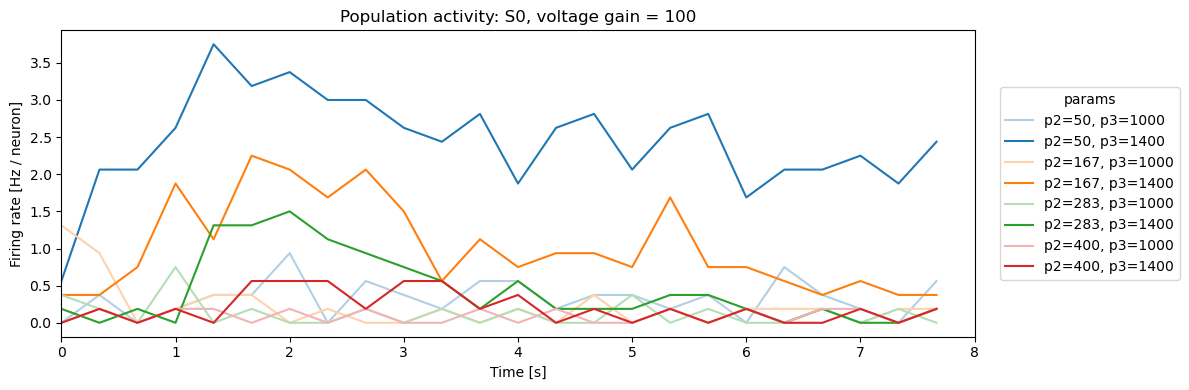

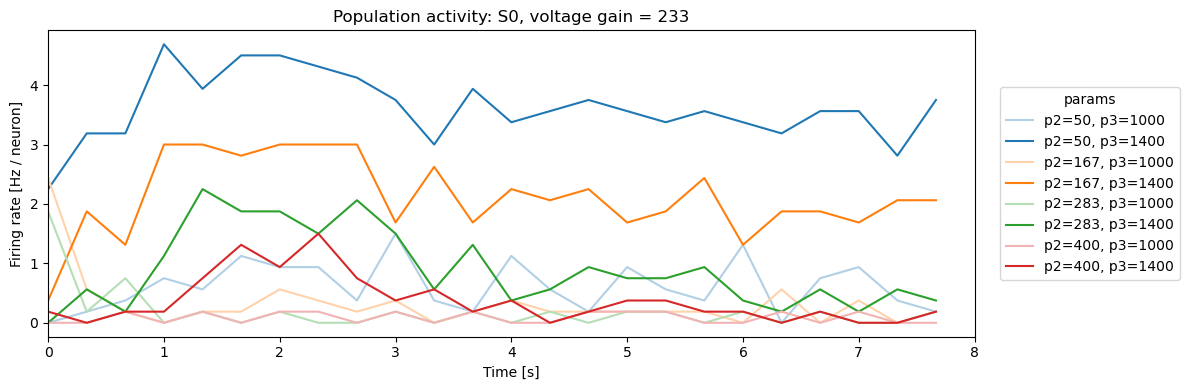

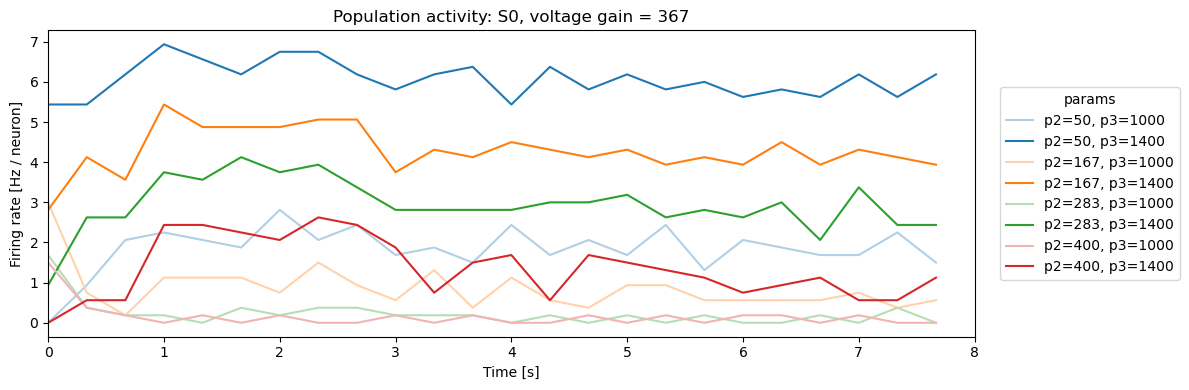

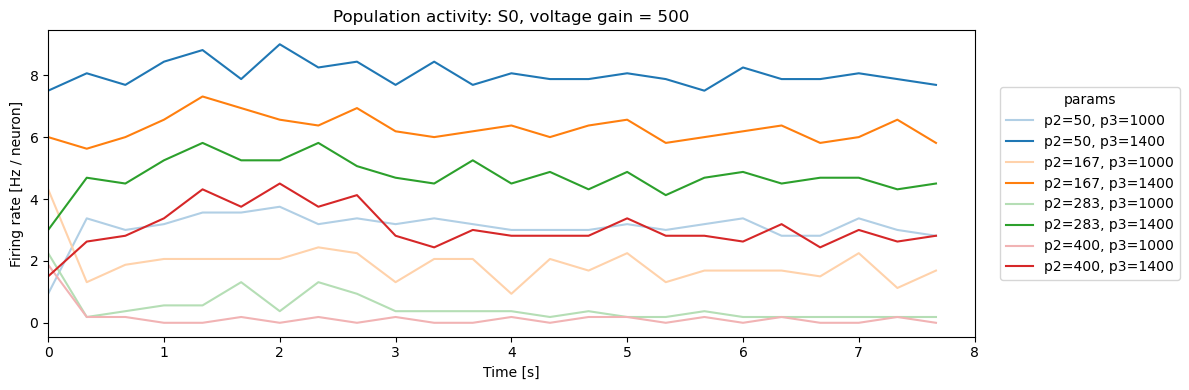

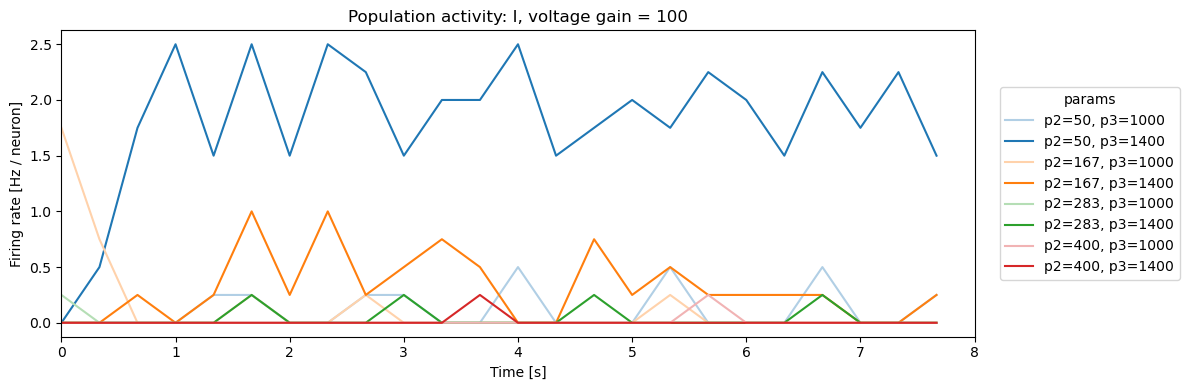

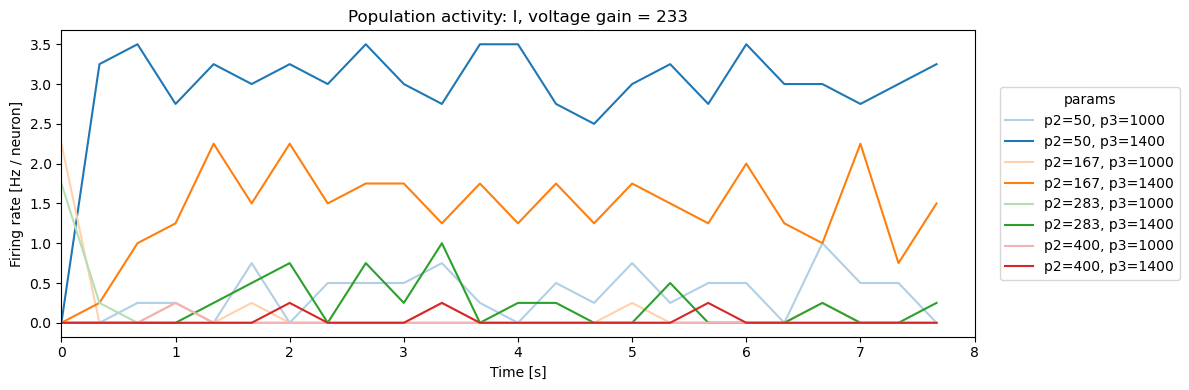

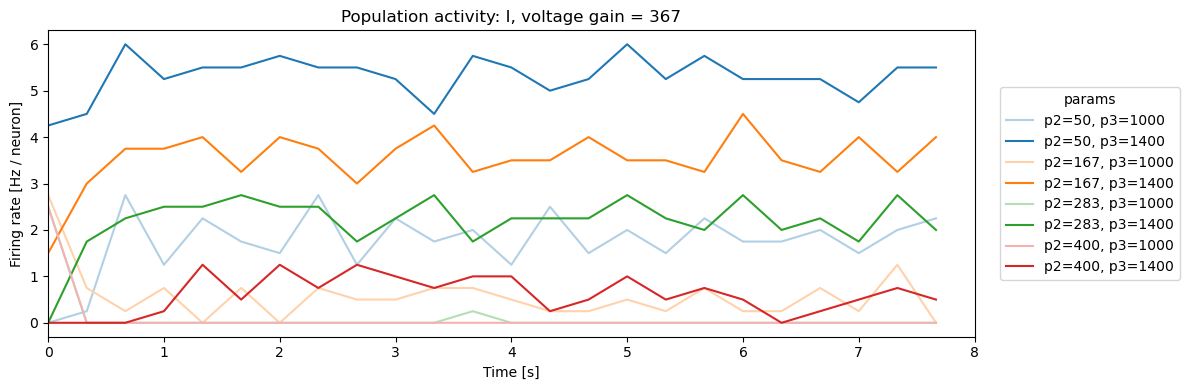

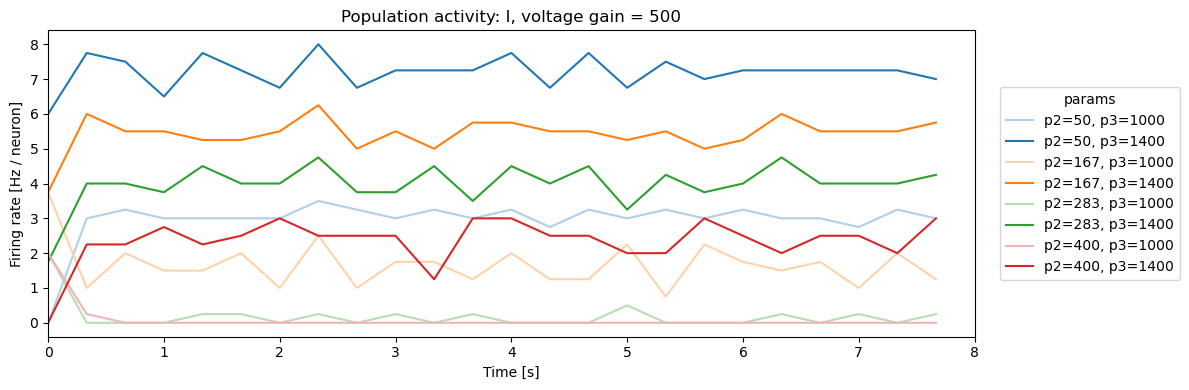

In [198]:
# ------------------------------------------------------------
# PLOT POPULATION ACTIVITY, ONE PLOT PER VOLTAGE GAIN
# param_2 -> base color
# param_3 -> shade of that color
# ------------------------------------------------------------

import matplotlib.colors as mcolors

voltage_gain_vals = sorted(set(data["param_1"] for data in sweep_data))
param_2_vals      = sorted(set(data["param_2"] for data in sweep_data))
param_3_vals      = sorted(set(data["param_3"] for data in sweep_data))

base_cmap = plt.get_cmap("tab10")

base_colors = {
    param_2: base_cmap(i % 10)
    for i, param_2 in enumerate(param_2_vals)
}

shade_vals = np.linspace(0.35, 1.0, len(param_3_vals))

shade_map = {
    param_3: shade_vals[i]
    for i, param_3 in enumerate(param_3_vals)
}


def make_shade(base_color, shade):
    """
    shade = 0 gives white
    shade = 1 gives the original base color
    """
    rgb = np.array(mcolors.to_rgb(base_color))
    white = np.array([1.0, 1.0, 1.0])

    return white * (1 - shade) + rgb * shade


for pop_idx, pop_label in enumerate(pop_labels):

    for voltage_gain in voltage_gain_vals:

        fig, ax = plt.subplots(figsize=(12, 4))

        for param_2 in param_2_vals:

            for param_3 in param_3_vals:

                matching_data = [
                    data for data in sweep_data
                    if (
                        data["param_1"] == voltage_gain and
                        data["param_2"] == param_2 and
                        data["param_3"] == param_3
                    )
                ]

                if len(matching_data) == 0:
                    continue

                data = matching_data[0]

                color = make_shade(
                    base_colors[param_2],
                    shade_map[param_3]
                )

                ax.plot(
                    t_axis,
                    data["binPOP_rate"][pop_idx],
                    color = color,
                    label = f"p2={param_2}, p3={param_3}",
                )

        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Firing rate [Hz / neuron]")
        ax.set_title(
            f"Population activity: {pop_label}, "
            f"voltage gain = {voltage_gain}"
        )
        ax.set_xlim(0, t_tot)

        ax.legend(
            title          = "params",
            loc            = "center left",
            bbox_to_anchor = (1.02, 0.5),
        )

        plt.tight_layout()
        plt.show()

In [199]:
raster_run_idx = 30
data = sweep_data[raster_run_idx]

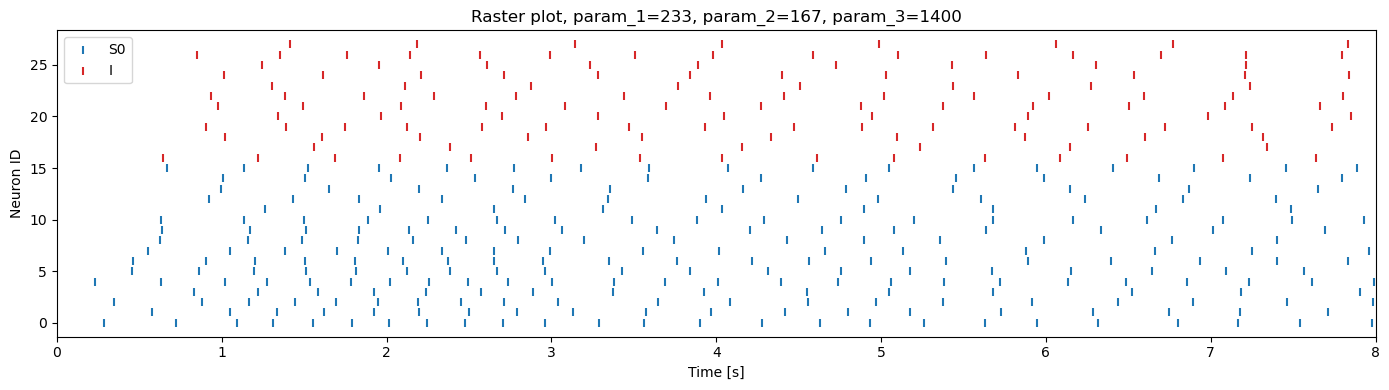

In [206]:
# ------------------------------------------------------------
# PLOT RASTER FOR ONE CHOSEN PARAMETER COMBINATION
# ------------------------------------------------------------

color_I = 'tab:red'
color_S = ['tab:blue', 'tab:orange', 'tab:green', color_I]  # one per S population

# Choose parameter combination to raster-plot
raster_param_1 = param_sweep_vals_1[1]   # voltage gain
raster_param_2 = param_sweep_vals_2[1]
raster_param_3 = param_sweep_vals_3[1]

# Find matching run
matching_data = [
    data for data in sweep_data
    if (
        data["param_1"] == raster_param_1 and
        data["param_2"] == raster_param_2 and
        data["param_3"] == raster_param_3
    )
]

if len(matching_data) == 0:
    raise ValueError(
        f"No sweep_data found for "
        f"param_1={raster_param_1}, "
        f"param_2={raster_param_2}, "
        f"param_3={raster_param_3}"
    )

data = matching_data[0]


fig, ax = plt.subplots(figsize=(14, 4))

for s in range(NS_int):

    ax.scatter(
        data["S_spike_t"][s],
        data["S_spike_id"][s],
        marker = "|",
        color  = color_S[s],
        label  = f"S{s}",
    )

if data["I_spike_t"].size > 0:

    ax.scatter(
        data["I_spike_t"],
        data["I_spike_id"],
        marker = "|",
        color  = color_I,
        label  = "I",
    )

ax.set_xlabel("Time [s]")
ax.set_ylabel("Neuron ID")
ax.set_title(
    f"Raster plot, "
    f"param_1={data['param_1']}, "
    f"param_2={data['param_2']}, "
    f"param_3={data['param_3']}"
)
ax.set_xlim(0, t_tot)

ax.legend()
plt.tight_layout()
plt.show()